<center>
<img src="../images/numba-logo.png" width="400">

[github.com/numba/numba](https://github.com/numba/numba)
</center>

## Numba Ecosystem

Open source since 2012, Numba is backbone of many important projects in scientific computing.

**14 years** · **347 contributors** · **~2M+ downloads/day** · **3,000+ dependent packages**

Used by whisper, RAPIDS (cuDF/cuML), shap, umap-learn, and many more.

# Intro to Numba

Numba is an open source JIT compiler that turns Python into machine code via LLVM.

With this intro, lets break down the above sentence and understand what it means. 

- Python is easy to write but slow for numerical loops.
- C is fast but is syntax strict, and difficult to iterate on quick. 
- **Numba** gives you close to C speed, with Python syntax. 

To understand this, we'll time the same algorithm three ways- Python, C and (Python + Numba) and see how close to C can we get.

## Sum of Squares

Compute $\sum x_i^2$ over an array of one million numbers- loop over data.

### Python version

In [335]:
import time
import numpy as np

def sum_of_squares(arr):
    s = 0.0
    for x in arr:
        s += x * x
    return s

arr = np.arange(1, 1_000_001)
print(f'len(arr) = {len(arr)}')
print(f'arr[0], arr[1], arr[2], arr[3], ... arr[-1] = {arr[0]}, {arr[1]}, {arr[2]}, {arr[3]}, ... {arr[-1]}')


t0 = time.perf_counter()
result = sum_of_squares(arr)
py_sum_time = time.perf_counter() - t0

print(f"result = {result:.0f}")
print(f"time   = {py_sum_time * 1000:.1f} ms")

len(arr) = 1000000
arr[0], arr[1], arr[2], arr[3], ... arr[-1] = 1, 2, 3, 4, ... 1000000
result = 333333833333127552
time   = 84.3 ms


### C version

Same loop. But we need to: write a file, choose types, allocate memory, compile, then run.

In [336]:
%%writefile sum_sq.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

int main(void) {
    int n = 1000000;
    double *arr = malloc(n * sizeof(double));
    for (int i = 0; i < n; i++) arr[i] = i + 1;

    struct timespec t0, t1;
    clock_gettime(CLOCK_MONOTONIC, &t0);
    double s = 0.0;
    for (int i = 0; i < n; i++) s += arr[i] * arr[i];
    clock_gettime(CLOCK_MONOTONIC, &t1);

    double elapsed = (t1.tv_sec - t0.tv_sec) + (t1.tv_nsec - t0.tv_nsec) / 1e9;
    printf("result = %.0f\ntime   = %.3f ms\n", s, elapsed * 1000);
    free(arr);
}

Overwriting sum_sq.c


In [337]:
import shutil
CC = shutil.which('clang') or shutil.which('gcc')
CC = shutil.which('gcc')
print(f'using: {CC}')

using: /usr/bin/gcc


In [338]:
!{CC} -O1 -o sum_sq_O1 sum_sq.c && echo "--- {CC} -O1 ---" && ./sum_sq_O1

--- /usr/bin/gcc -O1 ---
result = 333333833333127552
time   = 1.441 ms


In [339]:
!{CC} -O2 -o sum_sq_O2 sum_sq.c && echo "--- {CC} -O2 ---" && ./sum_sq_O2
!{CC} -O3 -o sum_sq_O3 sum_sq.c && echo "--- {CC} -O3 ---" && ./sum_sq_O3

--- /usr/bin/gcc -O2 ---
result = 333333833333127552
time   = 0.892 ms
--- /usr/bin/gcc -O3 ---
result = 333333833333127552
time   = 0.592 ms


### with Numba

Same Python function. To use numba, all you need is to import and add one decorator around the function (`njit`).

In [340]:
import numpy as np
from numba import njit

@njit
def sum_of_squares_numba(arr):
    s = 0.0
    for x in arr:
        s += x * x
    return s

arr_np = np.arange(1, 1_000_001, dtype=np.float64)

# first call triggers compilation — don't include in timing
_ = sum_of_squares_numba(arr_np[:10])

t0 = time.perf_counter()
result = sum_of_squares_numba(arr_np)
nb_sum_time = time.perf_counter() - t0

print(f"result = {result:.0f}")
print(f"time   = {nb_sum_time * 1000:.3f} ms")

result = 333333833333127552
time   = 0.714 ms


### Sum of Squares: Side by Side

All variants- Python, C at three optimization levels, and Numba (median of 5 runs).

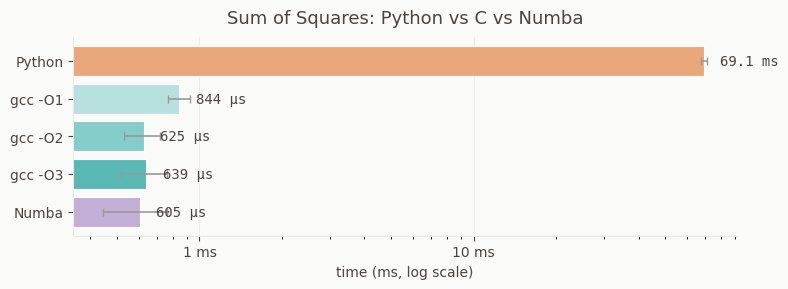

In [341]:
import subprocess, os
import matplotlib.pyplot as plt

RUNS = 5

def bench_py(func, *args):
    times = []
    for _ in range(RUNS):
        t0 = time.perf_counter()
        func(*args)
        times.append((time.perf_counter() - t0) * 1000)
    return np.median(times), np.std(times)

def bench_c(binary):
    times = []
    for _ in range(RUNS):
        out = subprocess.run([binary], capture_output=True, text=True).stdout
        times.append(float(out.strip().split("time   = ")[1].split(" ms")[0]))
    return np.median(times), np.std(times)

def fmt_t(ms):
    if ms >= 1:    return f"{ms:.1f} ms"
    if ms >= 0.01: return f"{ms*1000:.0f} \u00b5s"
    return f"{ms*1000:.1f} \u00b5s"

cc_name = os.path.basename(CC)
names = ["Python", f"{cc_name} -O1", f"{cc_name} -O2", f"{cc_name} -O3", "Numba"]
COLORS  = ["#e8a87c", "#b8e0de", "#85cdca", "#5ab8b4", "#c3aed6"]

results = [
    bench_py(sum_of_squares, arr),
    bench_c("./sum_sq_O1"),
    bench_c("./sum_sq_O2"),
    bench_c("./sum_sq_O3"),
    bench_py(sum_of_squares_numba, arr_np),
]
vals = [r[0] for r in results]
stds = [r[1] for r in results]

# reverse so fastest is at top
n_rev = names[::-1]
v_rev = vals[::-1]
s_rev = stds[::-1]
c_rev = COLORS[::-1]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(n_rev, v_rev, xerr=s_rev, color=c_rev,
               edgecolor="white", linewidth=0.8,
               error_kw=dict(ecolor="#999", lw=1.2, capsize=3))

ax.set_xscale("log")
ax.set_xlabel("time (ms, log scale)", fontsize=10, color="#4a4540")
ax.set_title("Sum of Squares: Python vs C vs Numba",
             fontsize=13, color="#4a4540", pad=10)

for bar, v in zip(bars, v_rev):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            fmt_t(v), va="center", fontsize=10, color="#4a4540",
            fontfamily="monospace")

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#ece8e3")
ax.tick_params(colors="#4a4540", labelsize=10)
ax.set_facecolor("#fafaf8")
fig.patch.set_facecolor("#fafaf8")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:g} ms"))
ax.grid(axis="x", color="#ece8e3", linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Under the hood, Numba uses **LLVM** — the same compiler backend as Clang/C++ — to generate optimized machine code the first time you call the function.

---

## Type Specialization

Numba is a **type-specializing** compiler. Each time it sees a new input type, it compiles a new version of the function optimized for that type.

In [342]:
@njit
def add_one(x):
    return x + 1

add_one(1)       # compiles for int
add_one(12.34)   # compiles again for float

add_one.signatures

[(int64,), (float64,)]

Two signatures — one for `int64`, one for `float64`. Same Python function, two different machine code paths. Specialization is where the speed comes from.

---

## Where Numba Can't Help

Numba compiles **loops over numbers and arrays**. It can't optimize code that uses Python objects or third-party libraries:

In [343]:
from numba import jit
import pandas as pd

x = {'a': [1, 2, 3], 'b': [20, 30, 40]}

@jit
def use_pandas(a): # Function will not benefit from Numba jit
    df = pd.DataFrame.from_dict(a) # Numba doesn't know about pd.DataFrame
    df += 1                        # Numba doesn't understand what this is
    return df.cov()                # or this!

print(use_pandas(x))

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
non-precise type pyobject
During: typing of argument at /var/folders/n8/13md7cz10tx910vqxf6lt6_w0000gn/T/ipykernel_20071/2792547010.py (6)

File "../../../../../var/folders/n8/13md7cz10tx910vqxf6lt6_w0000gn/T/ipykernel_20071/2792547010.py", line 6:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference 

This error may have been caused by the following argument(s):
- argument 0: Cannot determine Numba type of <class 'dict'>


## Resources

- **5 minute guide** — [numba.pydata.org/numba-doc/dev/user/5minguide.html](https://numba.pydata.org/numba-doc/dev/user/5minguide.html)
- **Docs** — [numba.pydata.org](https://numba.pydata.org)
- **GitHub** — [github.com/numba/numba](https://github.com/numba/numba)
- **Discourse** — [numba.discourse.group](https://numba.discourse.group)